In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
from liesel_ptm.sim.create_data import generate_data, loc_fn, scale_fn, generate_show_data
import liesel_ptm.sim.sim_ptm_onion as sim
import liesel.goose as gs

import liesel_ptm as ptm
import plotnine as p9
import pandas as pd

In [3]:
key = jax.random.PRNGKey(42)
k1, k2 , k3= jax.random.split(key, 3)
shape = ptm.sample_shape(k1, nshape=15, scale=0.4).sample

In [4]:
df = generate_data(k2, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)
df_show = generate_show_data(shape=shape, values=(-1.0, 0.0, 1.0), index=3, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)


In [5]:
k3 = jax.random.PRNGKey(43)
df_test = generate_data(k3, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)

In [6]:
df.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,...,fx2_loc,fx3_loc,fx0_scale,fx1_scale,fx2_scale,fx3_scale,x0,x1,x2,x3
0,1.326072,-1.669289,-1.519135,0.495911,-2.774182,0.062401,0.064364,3.624322,1.376784,-2.454432,...,1.828805,0.297184,-0.426818,-0.638694,0.650196,0.135296,-0.426818,-0.045442,-1.085834,-0.419033
1,9.347966,0.394827,0.393377,0.564515,-1.568099,0.208441,0.652980,8.436440,2.308670,-0.731428,...,4.424263,-1.247643,-0.069723,2.180715,1.572962,-0.568005,-0.069723,1.569329,-1.437325,-0.663971
2,5.100143,0.187031,0.123434,0.907031,-1.024136,0.359107,0.549119,4.836007,1.412266,-0.678940,...,4.073518,-1.031543,-1.384054,0.398945,1.448261,-0.469623,-1.384054,0.773671,-1.714869,-0.622977
3,7.069764,0.455891,0.472655,0.744908,-1.325135,0.265767,0.681770,6.279258,1.733980,-0.774715,...,-0.478737,3.881500,-0.775065,0.791062,-0.170206,1.767101,-0.775065,0.981646,-0.043533,0.249312
4,-0.192230,-0.162633,-0.294264,1.211359,-0.770493,0.462785,0.384277,-0.048023,0.886701,-0.890741,...,2.239161,-2.834933,-1.154455,-0.823333,0.796091,-1.290639,-1.154455,-0.362409,0.320135,-1.527687


In [7]:
df_show.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,std_pdf,x0,x1,x2,x3
0,-4.435643,-4.139144,-4.000000,1.114446,-8.810580,0.000149,0.000032,-0.497307,0.951486,-8.860311,0.000142,0.0,0.0,0.0,-1.0
1,-4.399611,-4.101275,-3.959799,1.116963,-8.648327,0.000175,0.000038,-0.497307,0.951486,-8.698057,0.000167,0.0,0.0,0.0,-1.0
2,-4.363660,-4.063491,-3.919598,1.119475,-8.487702,0.000206,0.000044,-0.497307,0.951486,-8.537433,0.000196,0.0,0.0,0.0,-1.0
3,-4.327790,-4.025792,-3.879397,1.121981,-8.328705,0.000241,0.000052,-0.497307,0.951486,-8.378435,0.000230,0.0,0.0,0.0,-1.0
4,-4.292000,-3.988177,-3.839196,1.124481,-8.171331,0.000283,0.000062,-0.497307,0.951486,-8.221062,0.000269,0.0,0.0,0.0,-1.0


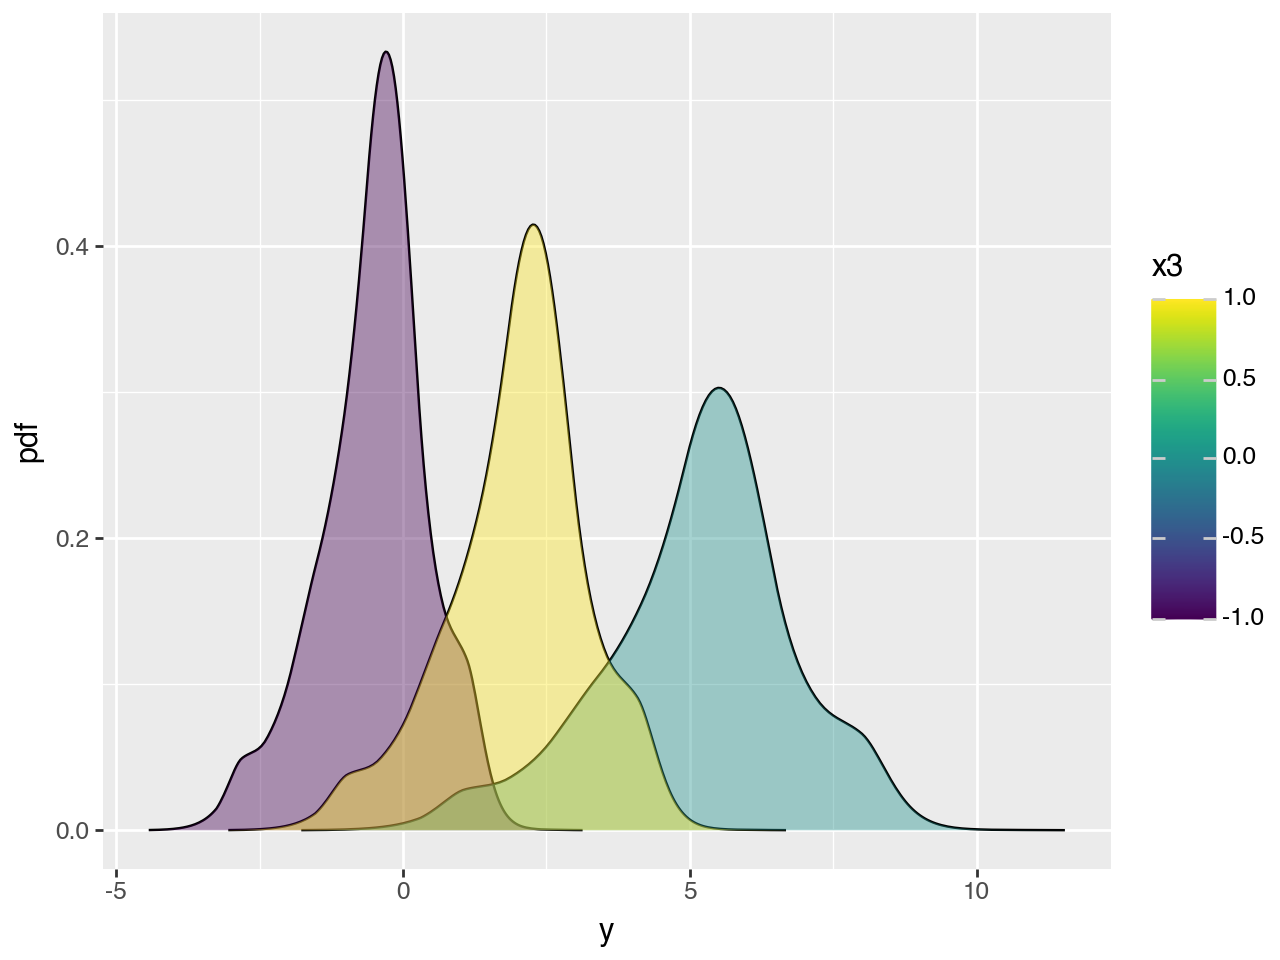

In [8]:
(
    p9.ggplot(df_show)
    + p9.aes("y", "pdf", group="x3")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf", fill="x3"), alpha=0.4)
)

In [9]:
model = sim.model_setup(
    df, 
    prior_tau2_covariates=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    prior_tau2_normalization=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    scale_terms=True,
    nshape=30,
    centered=False,
    scaled=False
)

In [10]:
fit = sim.model_fit(
    seed=1,
    model=model,
    warmup=1000,
    posterior=5000,
    sample_transformation=True,
    cache_path="cache/sim_onion_results.pickle"
)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.
Training loss: 1033.980, Validation loss: 1033.980:  12%|█▏        | 1209/9999 [00:29<02:31, 58.07it/s]liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 1209 iterations.
liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 1016.217, Validation loss: 1016.217:   8%|▊         | 776/9999 [00:33<02:24, 63.96it/s] liesel_ptm.model - INFO - Optimizing transformation parameters finished after 776 iterations.
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
Training loss: 1016.217, Validation loss: 1016.217:   8%|▊         | 776/9999 [00:49<02:24, 63.96it/s]liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 2

In [11]:
analysis = sim.model_analysis(
    model=model,
    results=fit[0],
    df=df,
    test_df=df_test,
    show_df=df_show,
    scale_terms=True,
    nshape=30,
    sample_transformation=True
)

In [12]:
list(analysis)

['param_df',
 'error_df',
 'summary_by_quantiles',
 'trafo_df',
 'mse_df',
 'mad_df',
 'kld_df',
 'waic_df',
 'waic_df_test',
 'quantile_score_df']

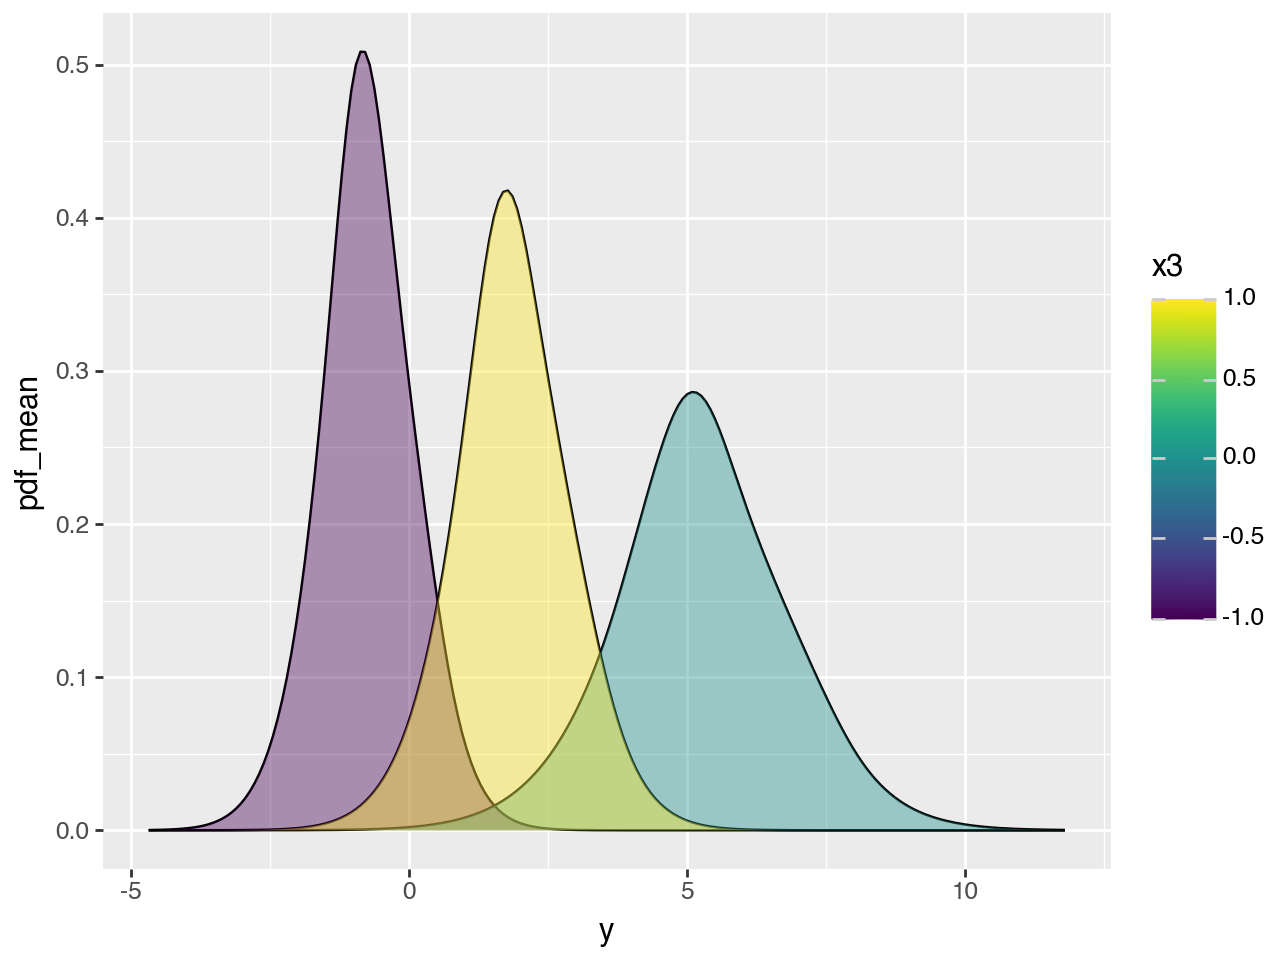

In [13]:
(
    p9.ggplot(analysis["summary_by_quantiles"])
    + p9.aes("y", "pdf_mean", group="x3")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf_mean", fill="x3"), alpha=0.4)
)

In [14]:
analysis["trafo_df"].head()

,z_mean,z_sd,z_median,z_lo,z_hi,pdf_mean,pdf_sd,pdf_median,pdf_lo,pdf_hi,cdf_mean,cdf_sd,cdf_median,cdf_lo,cdf_hi,residual
0,-6.714293,8.379118e-06,-6.714284,-6.714284,-6.714284,6.479802e-11,4.001734e-17,6.479806e-11,6.479806e-11,6.479806e-11,9.449583e-12,2.289855e-18,9.449585e-12,9.449585e-12,9.449585e-12,-6.714285
1,-6.669373,5.476633e-07,-6.669373,-6.669373,-6.669373,8.751549e-11,9.111445e-17,8.751540e-11,8.751540e-11,8.751540e-11,1.284495e-11,1.594810e-17,1.284497e-11,1.284497e-11,1.284497e-11,-6.669374
2,-6.624452,8.997604e-06,-6.624461,-6.624461,-6.624461,1.179592e-10,1.090063e-16,1.179593e-10,1.179593e-10,1.179593e-10,1.742586e-11,1.661894e-17,1.742587e-11,1.742587e-11,1.742587e-11,-6.624462
3,-6.579544,5.728808e-06,-6.579549,-6.579549,-6.579549,1.586732e-10,2.362671e-16,1.586735e-10,1.586735e-10,1.586735e-10,2.359379e-11,1.514272e-17,2.359381e-11,2.359381e-11,2.359381e-11,-6.579551
4,-6.534652,1.386003e-05,-6.534638,-6.534638,-6.534638,2.130100e-10,3.420742e-16,2.130096e-10,2.130096e-10,2.130096e-10,3.188187e-11,2.293102e-18,3.188187e-11,3.188187e-11,3.188187e-11,-6.534639


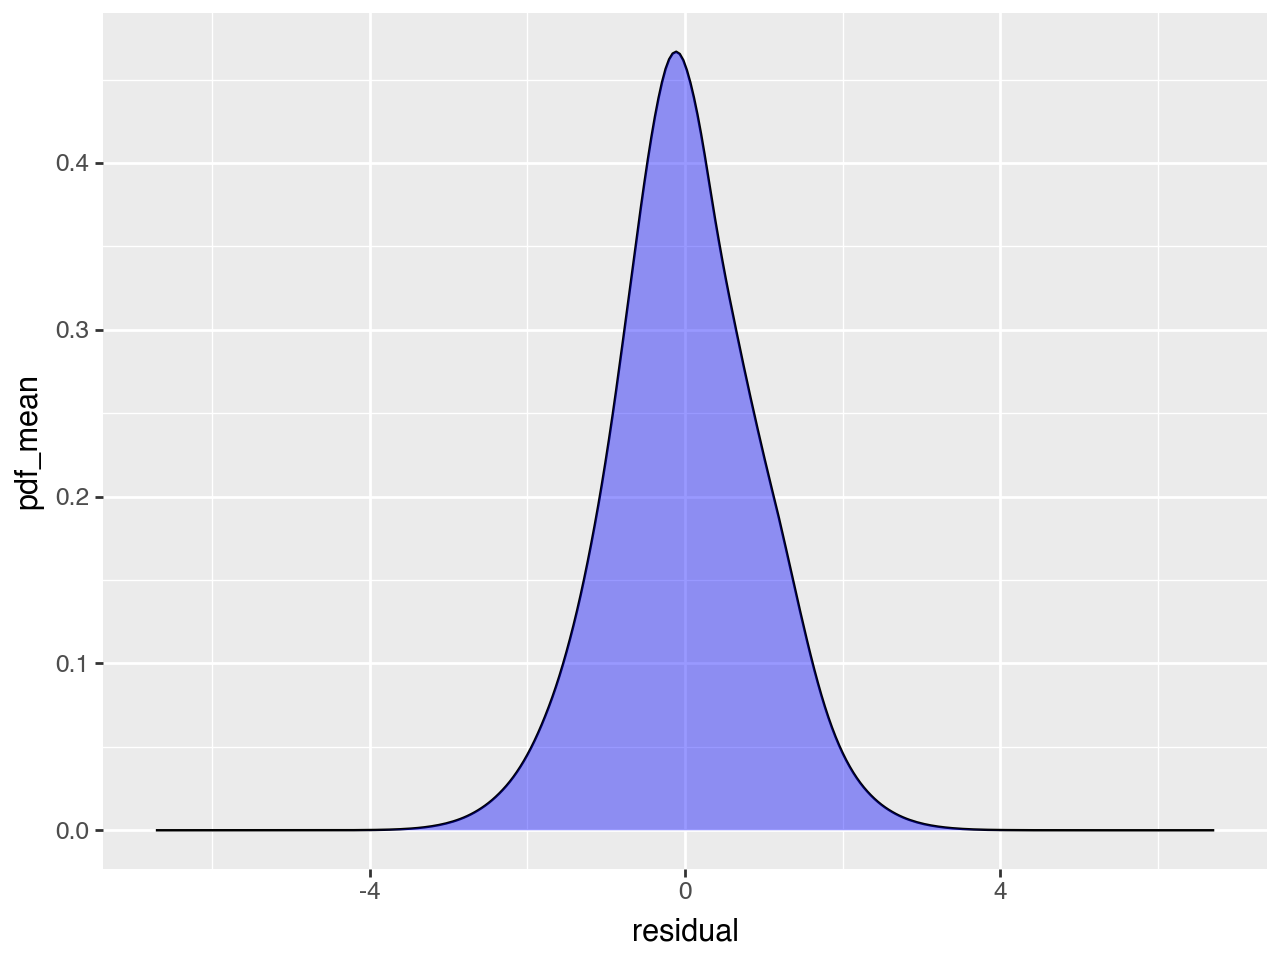

In [15]:
(
    p9.ggplot(analysis["trafo_df"])
    + p9.aes("residual", "pdf_mean")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf_mean"), fill="blue", alpha=0.4)
)

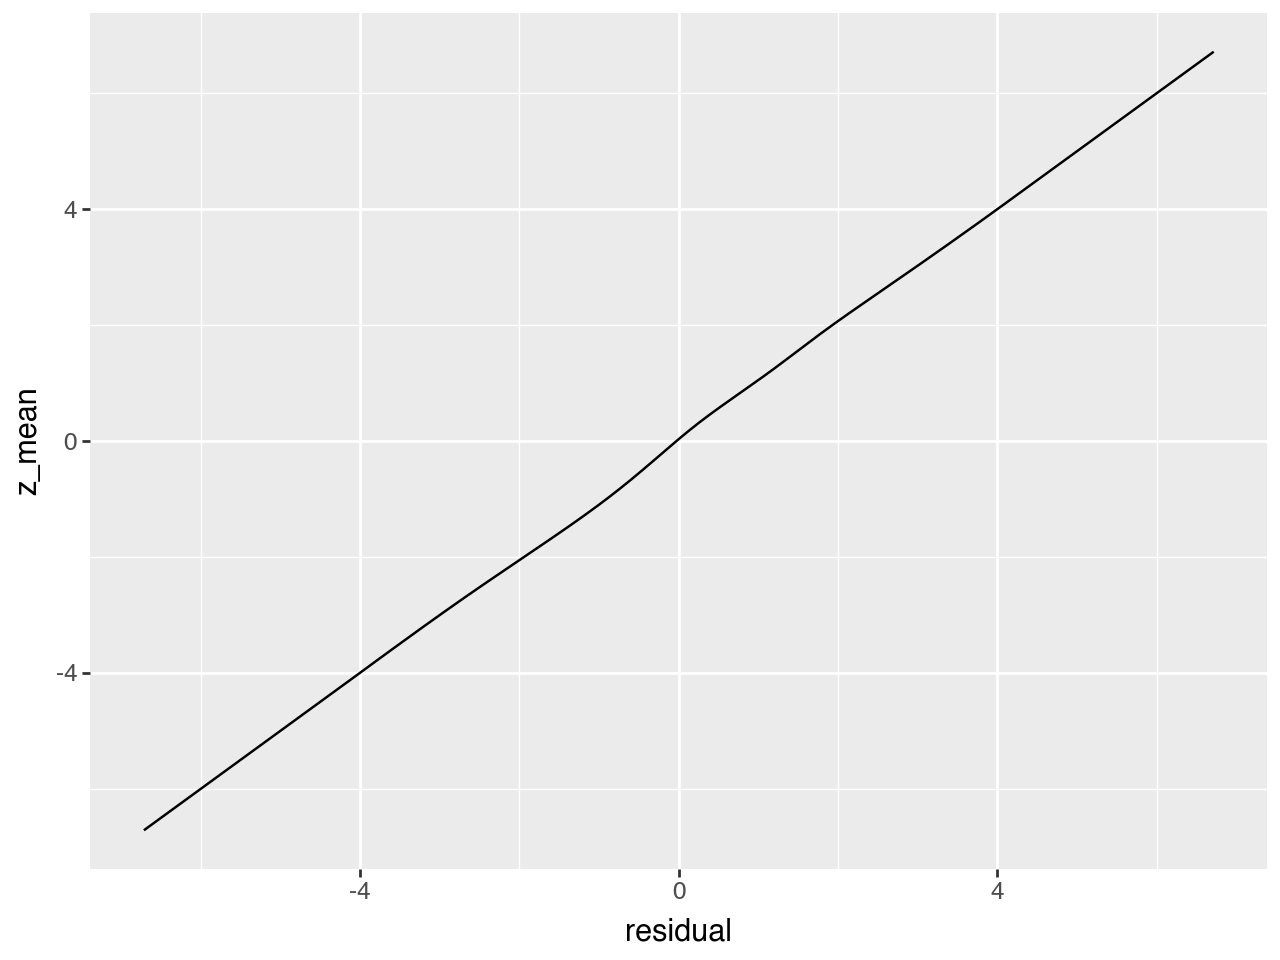

In [16]:
(
    p9.ggplot(analysis["trafo_df"])
    + p9.aes("residual", "z_mean")
    + p9.geom_line()
)

In [17]:
samples = fit[0].get_posterior_samples()

In [18]:
list(samples)

['loc_intercept',
 'normalization_tau2_transformed',
 'scale_intercept_exp',
 'shape_coef_latent_param',
 'x0_loc_coef',
 'x0_loc_tau2_transformed',
 'x0_scale_coef',
 'x0_scale_tau2_transformed',
 'x1_loc_coef',
 'x1_loc_tau2_transformed',
 'x1_scale_coef',
 'x1_scale_tau2_transformed',
 'x2_loc_coef',
 'x2_loc_tau2_transformed',
 'x2_scale_coef',
 'x2_scale_tau2_transformed',
 'x3_loc_coef',
 'x3_loc_tau2_transformed',
 'x3_scale_coef',
 'x3_scale_tau2_transformed']

In [19]:
samples["shape_coef_latent_param"][100, 100, :]

Array([-1.6248525 ,  1.3897368 ,  1.3510568 , -0.19655931,  2.3781312 ,
       -0.5306064 , -1.5517914 , -1.6057456 ,  0.40984243, -2.3571157 ,
        1.3927197 , -0.5792081 ,  1.259306  , -0.10632375,  1.3758149 ,
        1.1767759 , -0.13130568, -0.7850461 , -0.68314916,  1.8651487 ,
       -0.5123557 ,  0.51171786, -0.6747581 , -1.0025276 , -0.30271474,
       -0.30017126, -0.8309421 , -0.71441567, -0.09763891,  0.63845074],      dtype=float32)

In [20]:
dist = model.init_dist(samples)

liesel_ptm.model - INFO - Fixed value of x0_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_scale to corresponding node value.


In [21]:
dist = model.dist_class(model.knots.knots, model.coef.predict(samples), loc=0.0, scale=1.0)

In [22]:
e = jnp.linspace(-4, 4, 301)
pdf = dist.prob(e)

In [23]:
pdf.shape

(4, 5000, 301)

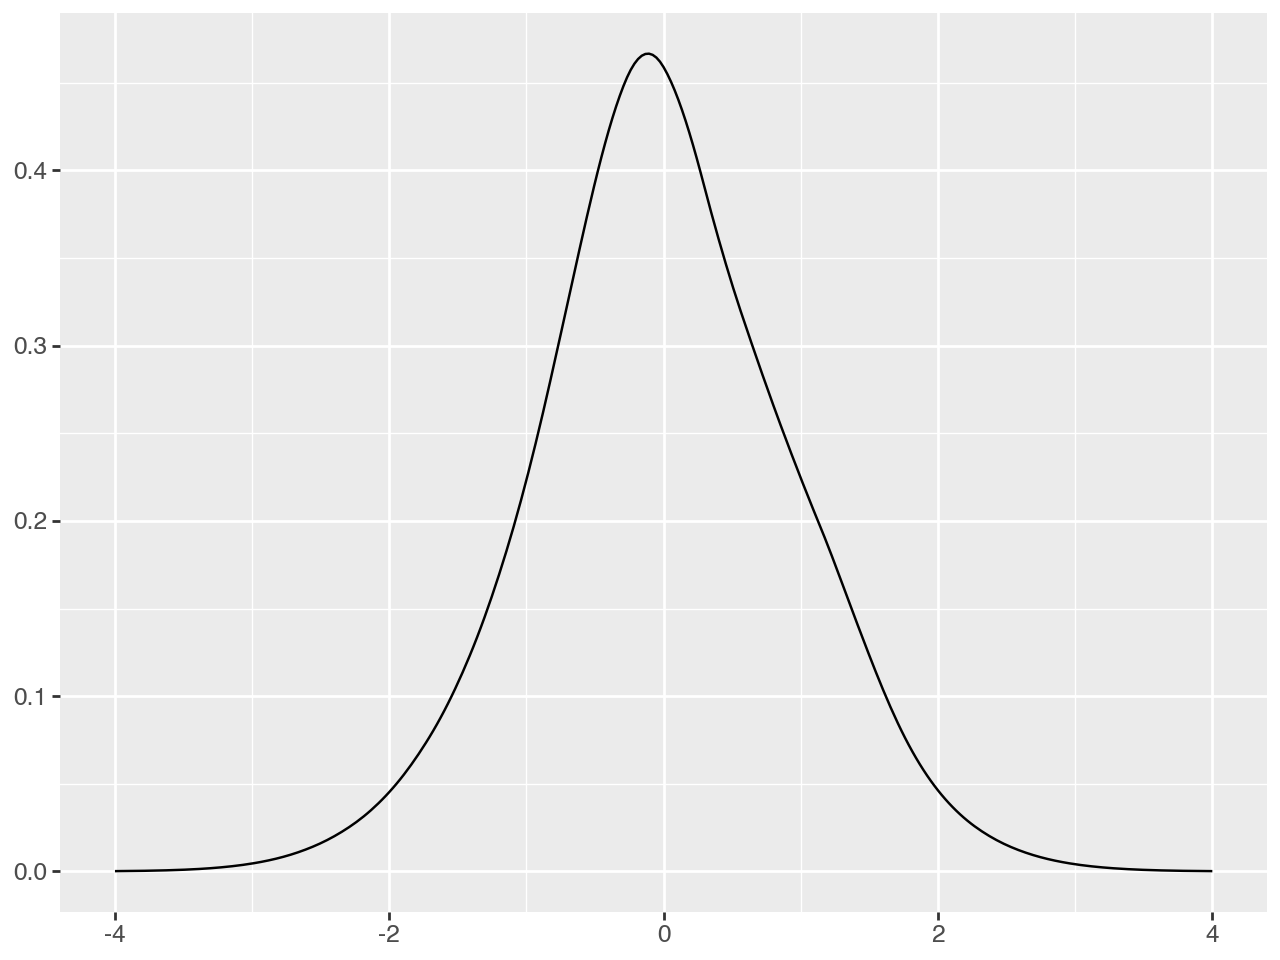

In [24]:
(
    p9.ggplot()
    + p9.aes(e, pdf.mean(axis=(0, 1)))
    + p9.geom_line()
)

In [25]:
gs.plot_trace(fit[0], "normalization_tau2_root_transformed")

KeyError: "All params must be in ['loc_intercept', 'normalization_tau2_transformed', 'scale_intercept_exp', 'shape_coef_latent_param', 'x0_loc_coef', 'x0_loc_tau2_transformed', 'x0_scale_coef', 'x0_scale_tau2_transformed', 'x1_loc_coef', 'x1_loc_tau2_transformed', 'x1_scale_coef', 'x1_scale_tau2_transformed', 'x2_loc_coef', 'x2_loc_tau2_transformed', 'x2_scale_coef', 'x2_scale_tau2_transformed', 'x3_loc_coef', 'x3_loc_tau2_transformed', 'x3_scale_coef', 'x3_scale_tau2_transformed']."

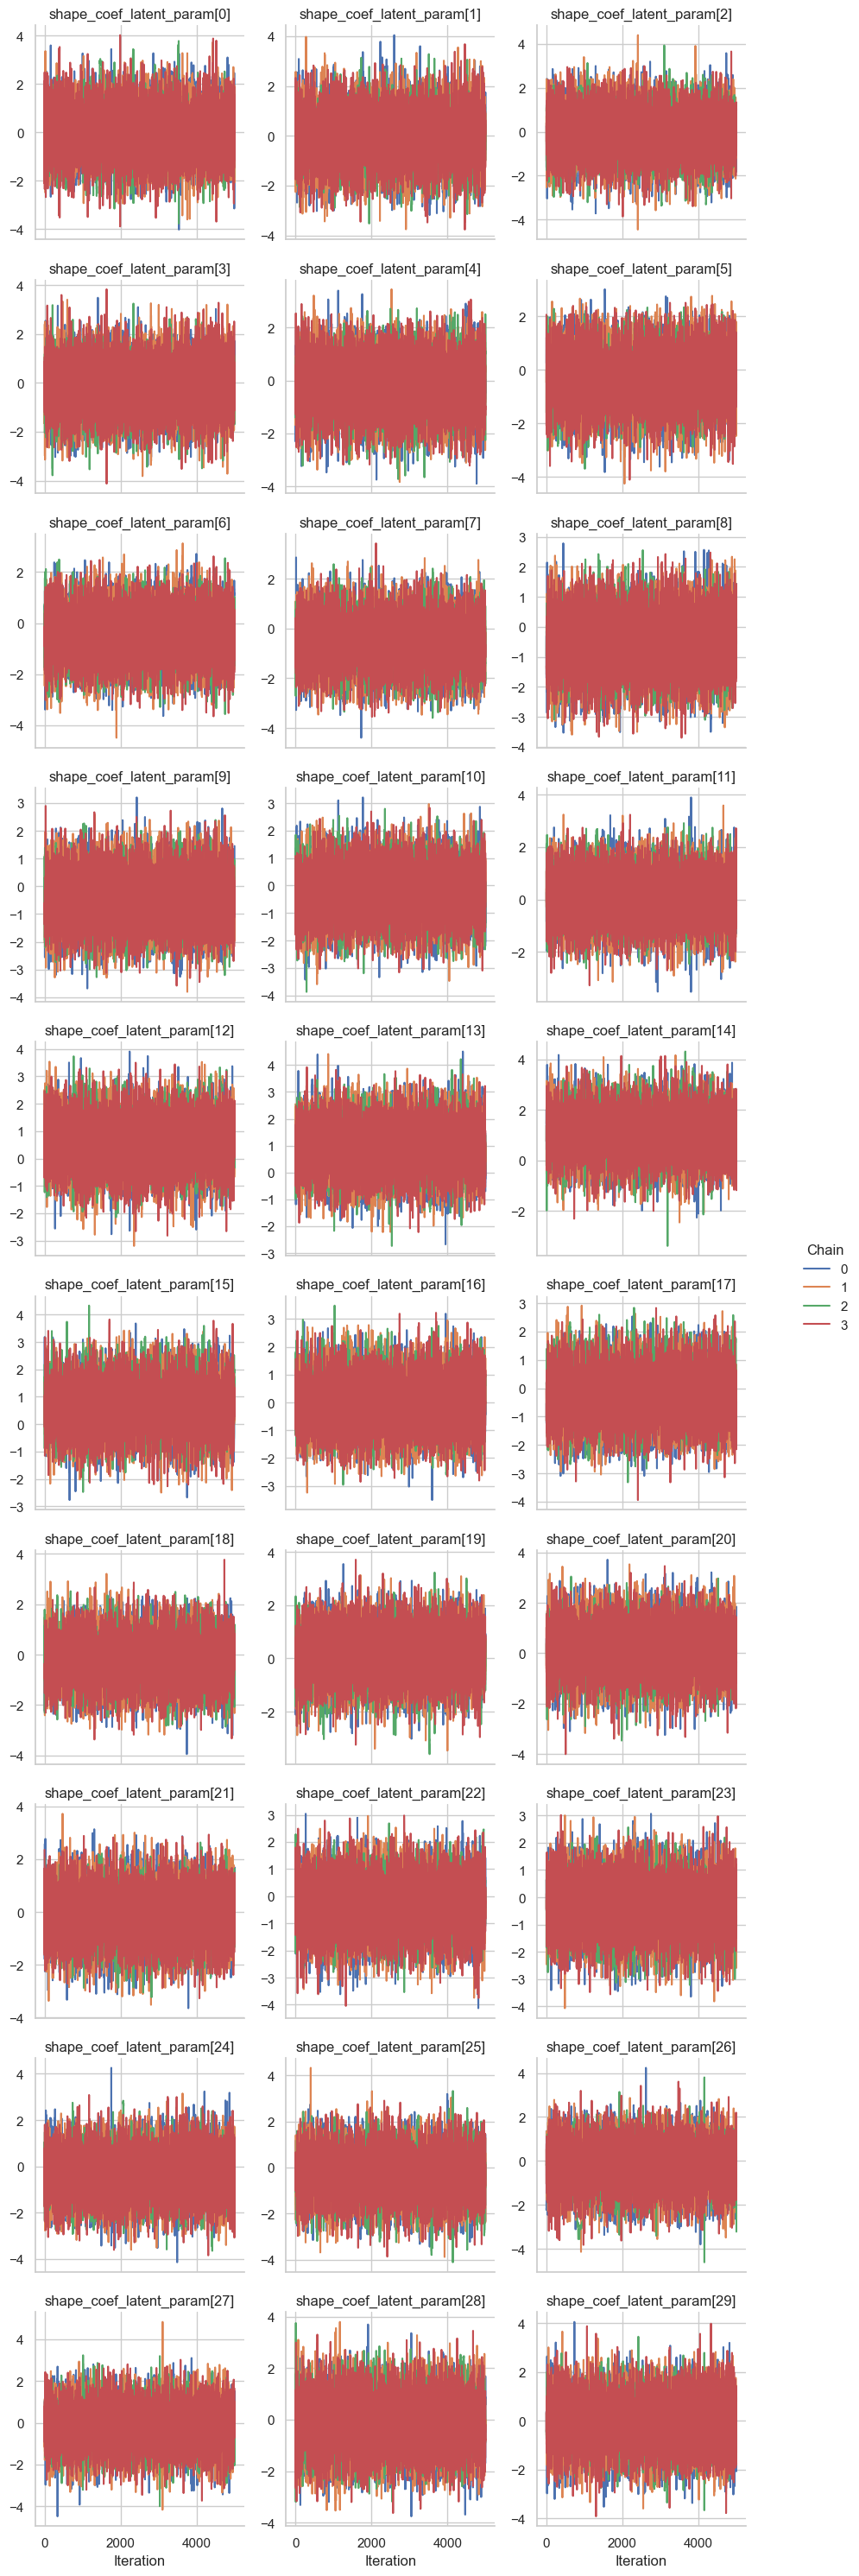

In [ ]:
gs.plot_trace(fit[0], "shape_coef_latent_param")

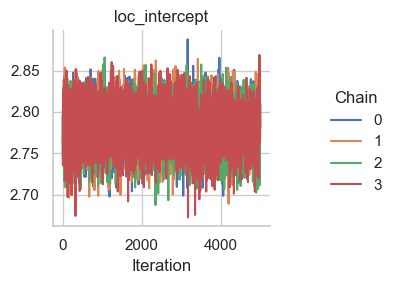

In [ ]:
gs.plot_trace(fit[0], "loc_intercept")

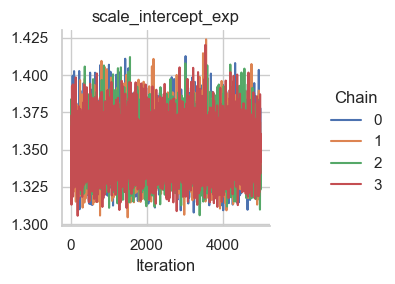

In [ ]:
gs.plot_trace(fit[0], "scale_intercept_exp")

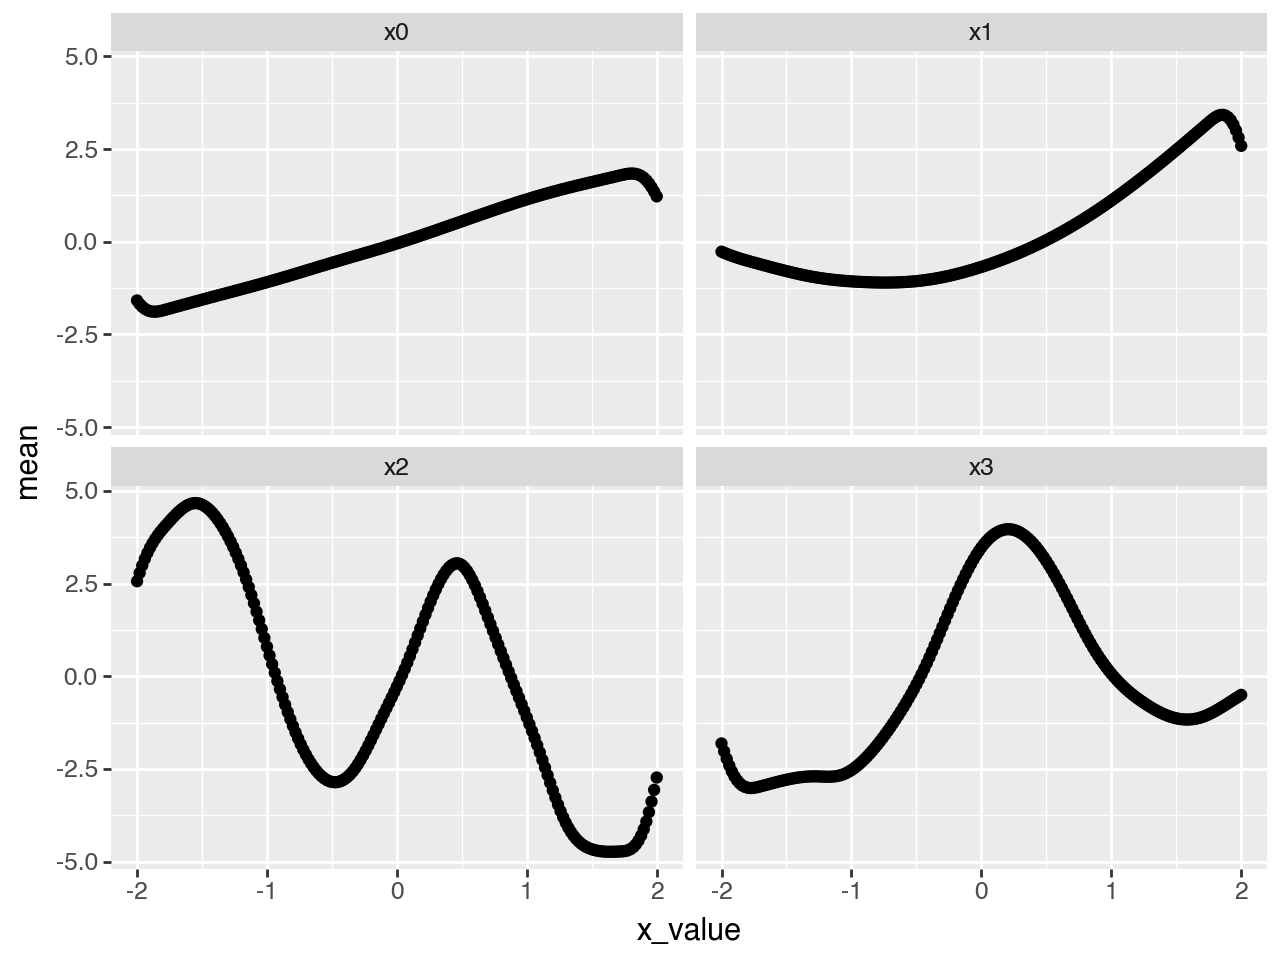

In [ ]:
x0_loc = model.loc_model.x0_loc.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x0_loc["x"] = "x0"

x1_loc = model.loc_model.x1_loc.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x1_loc["x"] = "x1"

x2_loc = model.loc_model.x2_loc.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x2_loc["x"] = "x2"

x3_loc = model.loc_model.x3_loc.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x3_loc["x"] = "x3"

loc_df = pd.concat([x0_loc, x1_loc, x2_loc, x3_loc])

(
    p9.ggplot(loc_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)

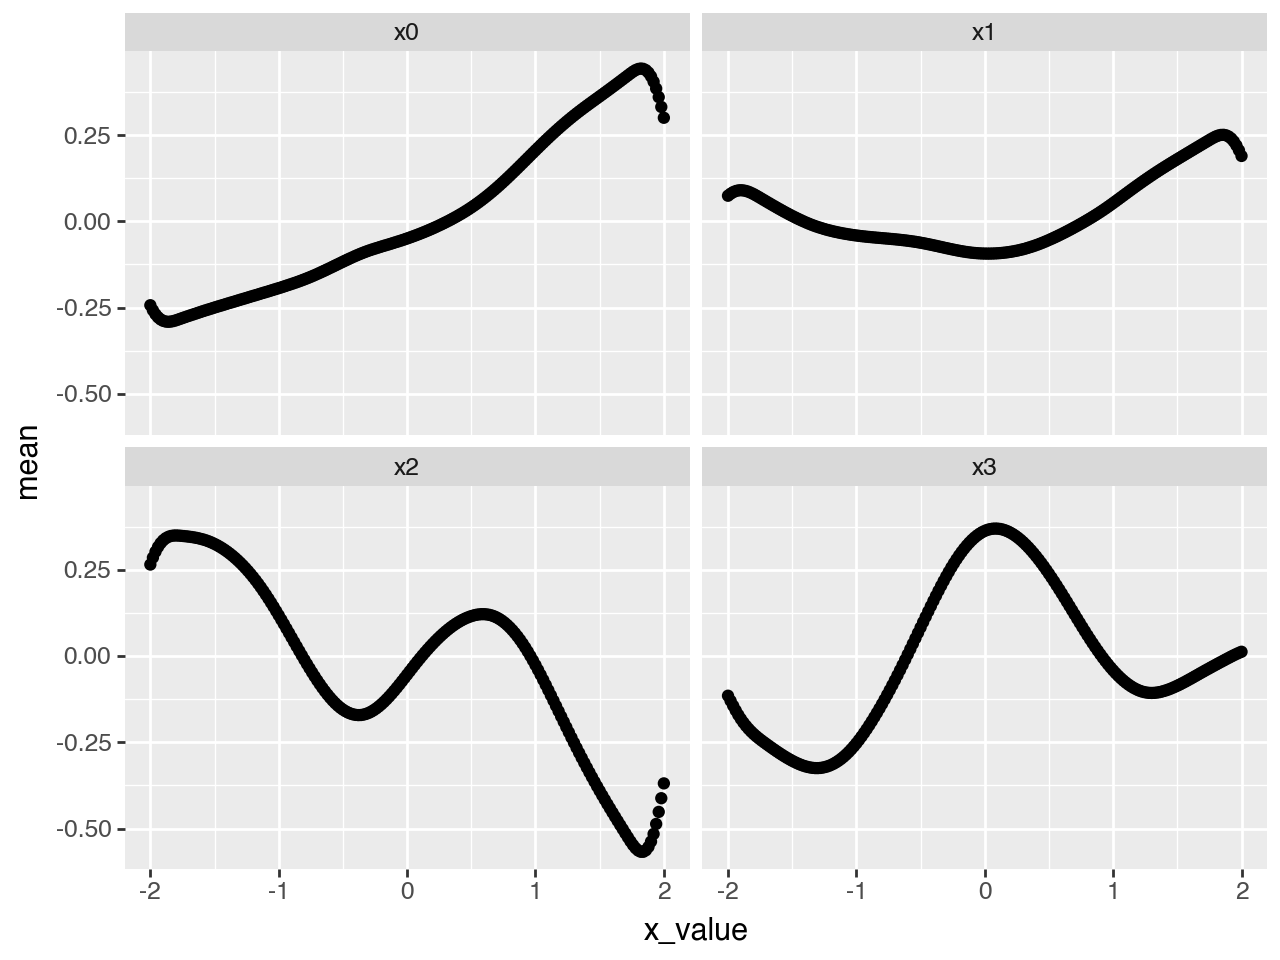

In [ ]:
x0_scale = model.log_scale_model.x0_scale.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x0_scale["x"] = "x0"

x1_scale = model.log_scale_model.x1_scale.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x1_scale["x"] = "x1"

x2_scale = model.log_scale_model.x2_scale.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x2_scale["x"] = "x2"

x3_scale = model.log_scale_model.x3_scale.summarise_by_quantiles(
    samples,
    x=jnp.linspace(-2, 2, 201),

)
x3_scale["x"] = "x3"

scale_df = pd.concat([x0_scale, x1_scale, x2_scale, x3_scale])

(
    p9.ggplot(scale_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)